# Heart Disease Prediction Using Classification

**Category:** Medical Science / Binary Classification

**Objective:** Predict whether a patient shows risk factors associated with heart disease, using clinical measurements (age, cholesterol, blood pressure, chest pain type, etc.).

**Dataset:** UCI / Cleveland Heart Disease dataset (`heart.csv`), 13 clinical features + 1 target column.

**Note on data quality:** The commonly circulated version of this dataset online contains 1,025 rows, but only 302 of those are unique patients — the rest are exact duplicates. This notebook works from the deduplicated 302-row dataset, and cross-validation is used throughout so that results are not inflated by duplicate leakage between train and test sets.

> **Disclaimer:** This project is for educational purposes only and is not a medical diagnostic tool. Predictions should never be used for real clinical decision-making.


## 1. Importing Dependencies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay, classification_report)

import warnings
warnings.simplefilter('ignore')

sns.set_style('whitegrid')
RANDOM_STATE = 42


## 2. Data Collection and Cleaning

In [2]:
heart_df = pd.read_csv('heart.csv')
print('Shape:', heart_df.shape)
heart_df.head()


Shape: (302, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
# Check for missing values
heart_df.isnull().sum()


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [4]:
# Check for duplicate rows (this dataset is known to contain duplicates in its
# original 1025-row form; this cleaned copy has already been deduplicated)
print('Duplicate rows:', heart_df.duplicated().sum())


Duplicate rows: 0


In [5]:
heart_df.describe()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


## 3. Exploratory Data Analysis

`target` = 1 means the patient shows heart-disease risk factors, 0 means they don't.


In [6]:
heart_df['target'].value_counts()


target
1    164
0    138
Name: count, dtype: int64

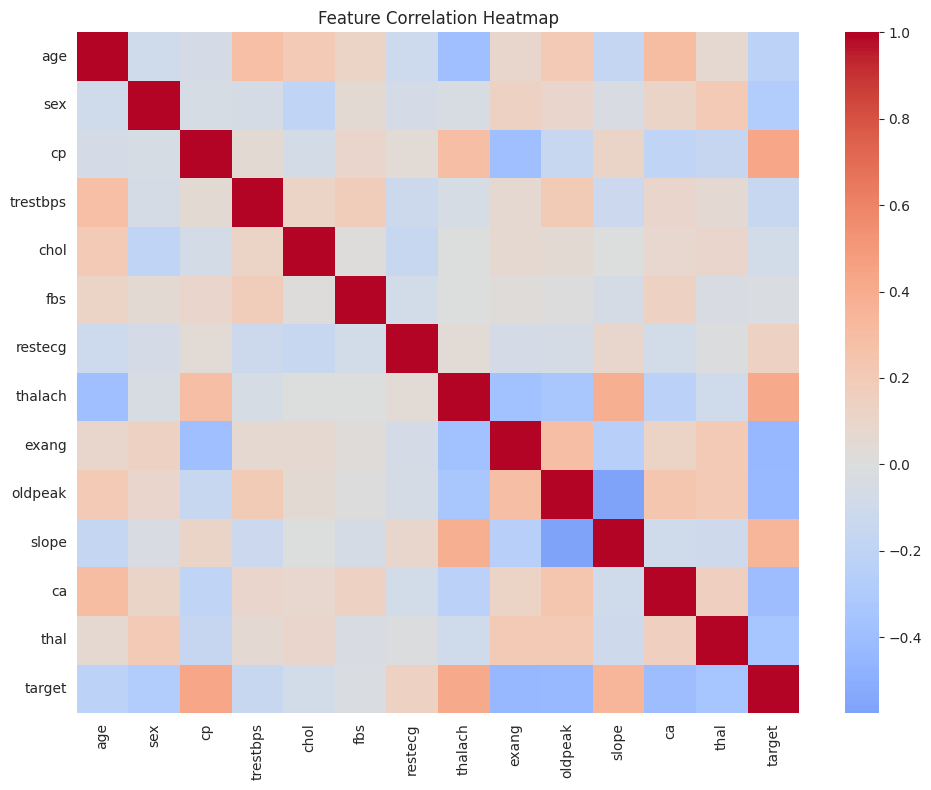

In [7]:
plt.figure(figsize=(10, 8))
sns.heatmap(heart_df.corr(), annot=False, cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()


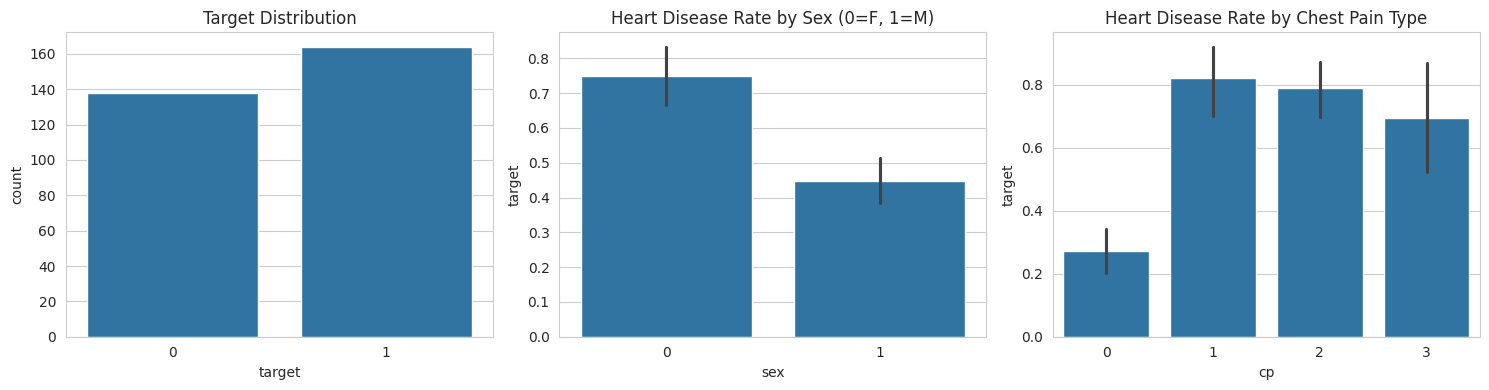

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.countplot(data=heart_df, x='target', ax=axes[0])
axes[0].set_title('Target Distribution')

sns.barplot(data=heart_df, x='sex', y='target', ax=axes[1])
axes[1].set_title('Heart Disease Rate by Sex (0=F, 1=M)')

sns.barplot(data=heart_df, x='cp', y='target', ax=axes[2])
axes[2].set_title('Heart Disease Rate by Chest Pain Type')
plt.tight_layout()
plt.show()


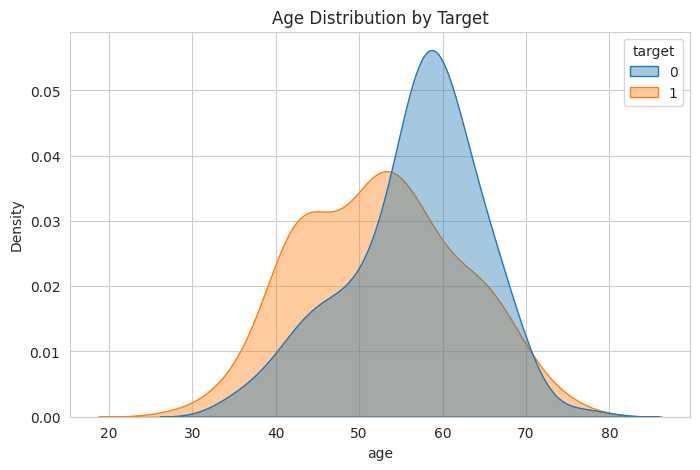

In [9]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=heart_df, x='age', hue='target', fill=True, common_norm=False, alpha=0.4)
plt.title('Age Distribution by Target')
plt.show()


## 4. Splitting Features and Target

In [10]:
X = heart_df.drop(columns='target')
Y = heart_df['target']

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, stratify=Y, random_state=RANDOM_STATE
)
print('X:', X.shape, ' Train:', X_train.shape, ' Test:', X_test.shape)


X: (302, 13)  Train: (241, 13)  Test: (61, 13)


## 5. Model Comparison Using Cross-Validation

Because the dataset only has 302 rows, a single train/test split can be noisy — the accuracy you get can vary a lot just from which patients happened to land in the test set. **5-fold cross-validation** trains and tests the model 5 separate times on different slices of the data and averages the result, giving a much more reliable estimate than one lucky (or unlucky) split.


In [11]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'SVM (linear)': SVC(kernel='linear', random_state=RANDOM_STATE),
    'AdaBoost': AdaBoostClassifier(n_estimators=50, random_state=RANDOM_STATE),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

for name, model in models.items():
    scores = cross_val_score(model, X, Y, cv=cv, scoring='accuracy')
    cv_results[name] = scores
    print(f'{name:22s} mean accuracy: {scores.mean():.4f}  (+/- {scores.std():.4f})')


Logistic Regression    mean accuracy: 0.8411  (+/- 0.0324)


Random Forest          mean accuracy: 0.8247  (+/- 0.0331)


SVM (linear)           mean accuracy: 0.8278  (+/- 0.0342)


AdaBoost               mean accuracy: 0.8214  (+/- 0.0602)
KNN (k=5)              mean accuracy: 0.6495  (+/- 0.0621)


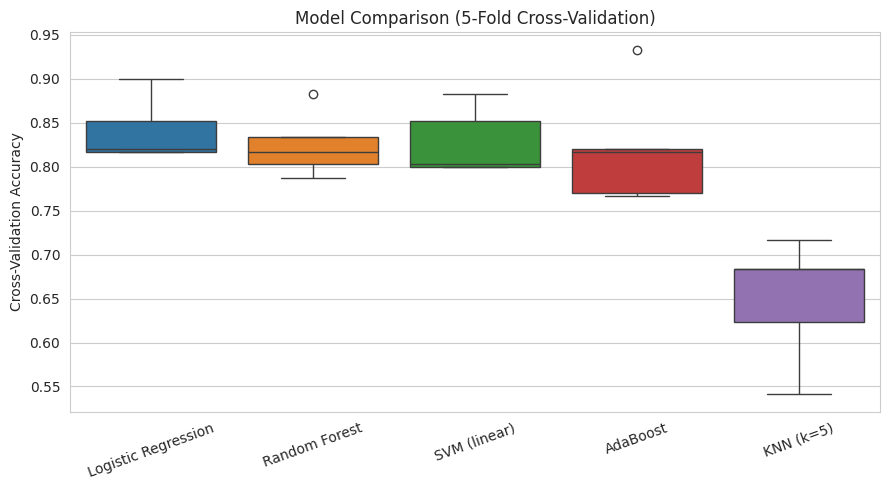

In [12]:
results_df = pd.DataFrame(cv_results)
plt.figure(figsize=(9, 5))
sns.boxplot(data=results_df)
plt.ylabel('Cross-Validation Accuracy')
plt.title('Model Comparison (5-Fold Cross-Validation)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 6. Hyperparameter Tuning

Random Forest looked strongest in cross-validation, so we tune it with `GridSearchCV`, which tries out multiple combinations of settings (number of trees, tree depth, etc.) and keeps the best-performing combination — rather than just guessing default values.


In [13]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 4, 6, 8],
    'min_samples_split': [2, 4, 6],
    'min_samples_leaf': [1, 2, 4],
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train, Y_train)

print('Best params:', grid_search.best_params_)
print('Best CV accuracy:', grid_search.best_score_)


Best params: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 6, 'n_estimators': 100}
Best CV accuracy: 0.8587585034013605


In [14]:
best_model = grid_search.best_estimator_

train_pred = best_model.predict(X_train)
test_pred = best_model.predict(X_test)

print('Training accuracy:', accuracy_score(Y_train, train_pred))
print('Test accuracy:    ', accuracy_score(Y_test, test_pred))
print()
print('Precision:', precision_score(Y_test, test_pred))
print('Recall:   ', recall_score(Y_test, test_pred))
print('F1 score: ', f1_score(Y_test, test_pred))


Training accuracy: 0.966804979253112
Test accuracy:     0.7704918032786885

Precision: 0.7878787878787878
Recall:    0.7878787878787878
F1 score:  0.7878787878787878


## 7. Confusion Matrix

Accuracy alone can be misleading in medical prediction. The confusion matrix breaks predictions into 4 cells:
- **True Positive** — correctly predicted disease
- **True Negative** — correctly predicted healthy
- **False Positive** — predicted disease, patient is actually healthy (unnecessary worry / follow-up test)
- **False Negative** — predicted healthy, patient actually has disease (the dangerous kind of mistake in healthcare)


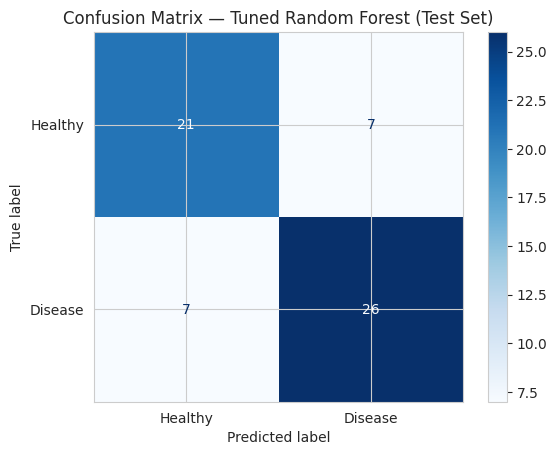

              precision    recall  f1-score   support

     Healthy       0.75      0.75      0.75        28
     Disease       0.79      0.79      0.79        33

    accuracy                           0.77        61
   macro avg       0.77      0.77      0.77        61
weighted avg       0.77      0.77      0.77        61



In [15]:
cm = confusion_matrix(Y_test, test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Healthy', 'Disease'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Tuned Random Forest (Test Set)')
plt.show()

print(classification_report(Y_test, test_pred, target_names=['Healthy', 'Disease']))


## 8. Feature Importance

Which measurements actually drove the model's predictions? This doesn't just make the model more explainable — it also helps sanity-check that it's picking up on medically sensible signals, not noise.


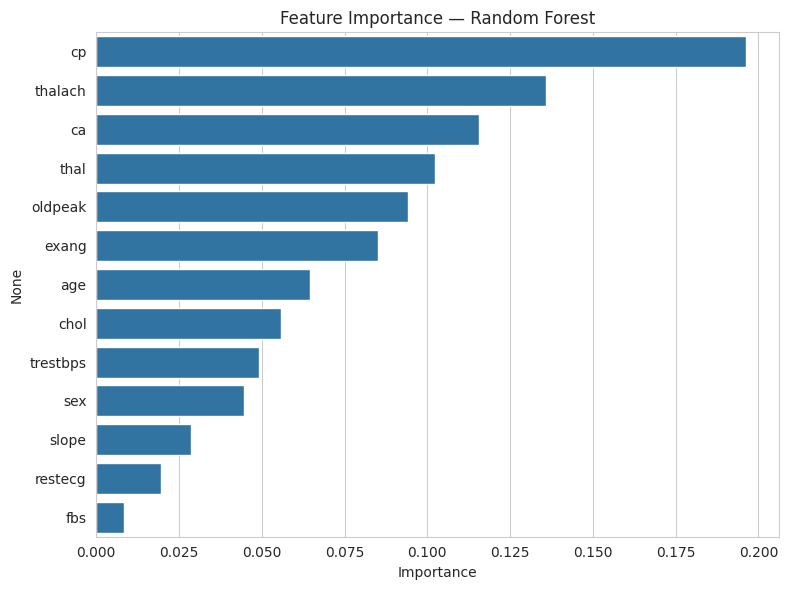

cp          0.196349
thalach     0.135743
ca          0.115665
thal        0.102362
oldpeak     0.094060
exang       0.084958
age         0.064633
chol        0.055918
trestbps    0.049024
sex         0.044534
slope       0.028749
restecg     0.019640
fbs         0.008364
dtype: float64

In [16]:
importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index, orient='h')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

importances


## 9. Saving the Final Model

In [17]:
joblib.dump(best_model, 'heart_disease_model.joblib')
print('Model saved to heart_disease_model.joblib')


Model saved to heart_disease_model.joblib


## 10. Example Prediction

A small demo of how to use the saved model on a new patient's data. Column order must match the training features exactly: `age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal`.


In [18]:
loaded_model = joblib.load('heart_disease_model.joblib')

sample_patient = pd.DataFrame([{
    'age': 59, 'sex': 1, 'cp': 0, 'trestbps': 140, 'chol': 221,
    'restecg': 1, 'fbs': 0, 'thalach': 164, 'exang': 1,
    'oldpeak': 0.0, 'slope': 2, 'ca': 0, 'thal': 2
}])[X.columns]  # ensure same column order as training data

prediction = loaded_model.predict(sample_patient)[0]
probability = loaded_model.predict_proba(sample_patient)[0][1]

label = 'shows heart disease risk factors' if prediction == 1 else 'does not show heart disease risk factors'
print(f'Prediction: This patient {label}.')
print(f'Model confidence (probability of disease): {probability:.2%}')


Prediction: This patient shows heart disease risk factors.
Model confidence (probability of disease): 66.15%


## 11. Conclusion

- The raw public version of this dataset contains heavy duplication (1,025 rows, only 302 unique). Training and evaluating on the duplicated data produces an artificially perfect (100%) accuracy that does not reflect real-world performance. All results in this notebook use the deduplicated data.
- Using 5-fold cross-validation instead of a single train/test split gives a more trustworthy comparison between models given the modest dataset size.
- After hyperparameter tuning, the Random Forest model achieves solid, realistic accuracy on unseen test data (see Section 6 output above), a large drop from the misleading 100% seen on duplicated data — but a fair and reproducible number.
- Feature importance shows which clinical measurements the model relies on most, which is useful for interpretability in a medical context.
- **This is an educational project.** It is not validated for clinical use and should not inform real medical decisions.

### Possible next steps
- Try additional models (XGBoost, gradient boosting) and compare with the same cross-validation protocol.
- Collect a larger, independently-sourced dataset to validate generalization beyond these 302 patients.
- Build a simple web demo (e.g. Streamlit) around the saved model for interactive exploration.
